# Data Acquisition and Preprocessing for K-Nearest Neighbors (KNN)
This module focuses on the critical first steps of the machine learning pipeline: importing data and preparing it specifically for the K-Nearest Neighbors algorithm. Because KNN relies on distance metrics (like Euclidean distance), it is hypersensitive to the scale and quality of your data.

**Environment Setup**
We will use the standard Python stack for data science. Ensure you have these libraries installed:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

**Importing Datasets**
There are three common ways to bring data into your environment.

A. Loading from a CSV/Excel File
The most common method for local or web-based files.

In [2]:
# From a local path or URL
# url = "https://raw.githubusercontent.com/archive/dataset/main/data.csv"
# df = pd.read_csv(url)
# print(df.head())

**Loading Built-in Scikit-Learn Datasets**
Perfect for testing and prototyping.

 The Iris dataset is built into Scikit-Learn. It contains 150 records of three different species of Iris flowers (Setosa, Versicolor, and Virginica).

 The Structure: The iris object is a "Bunch" (similar to a dictionary) containing:
 data: The physical measurements.
 target: The numeric labels ($0, 1, 2$).
 feature_names: The names of the measurements.

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()


While Scikit-Learn works with raw NumPy arrays, humans work better with DataFrames. This turns the raw numbers into a readable table

In [4]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)


This adds a final column to your table representing the species.

0: Setosa

1: Versicolor

2: Virginica

In [5]:
df['target'] = iris.target

**Essential Preprocessing for KNN**
KNN calculates the distance between points. If one feature ranges from 0–1 and another from 0–1000, the larger feature will dominate the distance calculation, making the model inaccurate.

Step 1: Handling Missing Values
KNN cannot handle NaN (Not a Number) values. You must either drop them or fill them (imputation).

In [6]:
# Option 1: Drop rows with missing values
df.dropna(inplace=True)

# Option 2: Impute with the mean/median
# df['column_name'] = df['column_name'].fillna(df['column_name'].mean())

**Step 2: Categorical Encoding** KNN requires numerical inputs. We convert text labels into numbers.Label Encoding: For target variables (e.g., "Setosa" $\rightarrow$ 0).One-Hot Encoding: For features (e.g., "Color: Red" $\rightarrow$ [1, 0, 0]).

LabelEncoder is a utility from the sklearn.preprocessing library.

The Purpose: Most machine learning models are based on mathematical equations that require numbers as input. They cannot perform calculations on strings like "Setosa" or "Versicolor."

In [7]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

Step 3: Feature Scaling (Crucial for KNN)
We use Standardization to give all features a mean of 0 and a standard deviation of 1.

The Math: This tool calculates the Z-score for every value. It shifts the data so the Mean ($\mu$) is 0 and the Standard Deviation ($\sigma$) is 1.The Formula:$$z = \frac{x - \mu}{\sigma}$$

In [8]:
scaler = StandardScaler()

You must never scale your target (the species/diagnosis). Scaling is only for the "inputs" (X), not the "answer" (y).

axis=1: This tells Pandas to drop the column named 'target' rather than a row

In [9]:
# We only scale the feature columns, not the target
features = df.drop('target', axis=1)

fit: The scaler calculates the mean and standard deviation for each of the 4 Iris features (sepal length, petal width, etc.).

transform: It applies the Z-score formula to every single number in the dataset.

Result: scaled_features is now a raw NumPy array where most values fall between -3 and 3.

In [10]:
scaled_features = scaler.fit_transform(features)

fit_transform returns a raw NumPy array, which loses the column names (the headers).

The Solution: You are wrapping that array back into a Pandas DataFrame and reapplying the original names (sepal length (cm), etc.). This makes it much easier to visualize or debug later.

In [11]:
df_feat = pd.DataFrame(scaled_features, columns=features.columns)

**Splitting the Dataset**
Before training, we must hide a portion of the data to test how the model performs on unseen information.

 The Inputs: Features ($X$) and Target ($y$)

 df_feat: These are your standardized features (Sepal/Petal dimensions) that you just scaled. This is your independent variable matrix, $X$.

 df['target']: This is your column of integers ($0, 1, 2$) representing the flower species. This is your dependent variable, $y$.

 test_size=0.30 (The 70/30 Split)

 The Logic: You are instructing the computer to take 70% of the data (105 flowers) to train the model and reserve 30% (45 flowers) for testing.

 The Purpose: If you test a model on the same data it studied, it will appear to have 100% accuracy (cheating). By hiding 30% of the data, you create a "blind test" that proves the model can handle flowers it has never seen before.

 random_state=42 (The Seed for Reproducibility)


 The Problem: By default, train_test_split shuffles the data randomly. If you run the code again, you might get a different split, which would change your accuracy scores slightly.

 The Solution: Setting a random_state (42 is a common "lucky" number in the ML community) ensures that the "random" shuffle is exactly the same every time you run the script.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df_feat,
    df['target'],
    test_size=0.30,
    random_state=42
)

**The KNN Concept**  KNN is a lazy learner. It doesn't "learn" a mathematical function; instead, it stores the entire training dataset and makes predictions based on the similarity (distance) between a new data point and its nearest neighbors.


**Basic Implementation** We use Scikit-Learn's KNeighborsClassifier. For this initial step, we will pick an arbitrary value of $K = 5$.

In [13]:
from sklearn.neighbors import KNeighborsClassifier

KNN is a lazy learner. It doesn't learn a complex formula; it simply stores all the training data.

n_neighbors=5: This is your hyperparameter ($k$). When the model sees a new flower, it looks at the 5 closest flowers in the training set (the "neighbors").

Voting System: If 4 neighbors are Versicolor and 1 is Virginica, the model predicts Versicolor (majority rules).



In [14]:
# Initialize the model
knn = KNeighborsClassifier(n_neighbors=5)

In most models, fit involves complex calculus. In KNN, the model is essentially "memorizing" the positions of the 105 flowers in your X_train set and their corresponding labels in y_train.

In [15]:
# Fit the model to the training data
knn.fit(X_train, y_train)

KNeighborsClassifier()

For each of the 45 flowers in your test set, the model:

Calculates the distance from that flower to every flower in the training set.

Finds the 5 closest ones.

Takes a majority vote.

The Output: predictions is an array of 45 integers ($0, 1, 2$) representing the model's guesses for those unseen flowers.

In [16]:
# Make predictions on the test set
predictions = knn.predict(X_test)

In [17]:
print("First 10 predictions:", predictions[:10])

First 10 predictions: [1 0 2 1 1 0 1 2 1 1]


**Model Evaluation**

To understand how well our model performed, we look at the Confusion Matrix and the Classification Report (which includes Precision, Recall, and F1-Score).

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

The confusion matrix is a square grid (in this case, $3 \times 3$ because we have 3 species) that compares the Actual Labels against the Predicted Labels.

The Diagonal: The numbers running from the top-left to the bottom-right are your True Positives. These represent the flowers the model identified correctly.

Off-Diagonal: Any number appearing outside that diagonal represents an error (a "confusion").

In [19]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [20]:
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



**Finding the Optimal K (The Elbow Method)** Choosing the right $K$ is the most important part of tuning a KNN model.

A low K (e.g., $K=1$) makes the model sensitive to noise (overfitting).

A high K makes the model too "smooth," potentially missing patterns (underfitting).

We use the Elbow Method by plotting the error rate for various $K$ values.

 "mini-experiment" 39 times. In each iteration, you change the number of neighbors ($k$).

 pred_i != y_test: This creates a list of True/False values (True if the model guessed wrong, False if correct).

 np.mean(...): Since True equals 1 and False equals 0, the average gives you the percentage of errors. For example, an error rate of $0.05$ means the model was $95\%$ accurate.

In [21]:
error_rate = []

# Testing K values from 1 to 40
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Understanding the Bias-Variance TradeoffThis loop helps you find the "sweet spot" in machine learning:

When $K$ is very small (e.g., $K=1$): The model is too sensitive to noise or outliers. It "overfits" the training data.

When $K$ is very large (e.g., $K=40$): The model becomes too "blunt" and ignores local patterns. It starts "underfitting" the data

Text(0, 0.5, 'Error Rate')

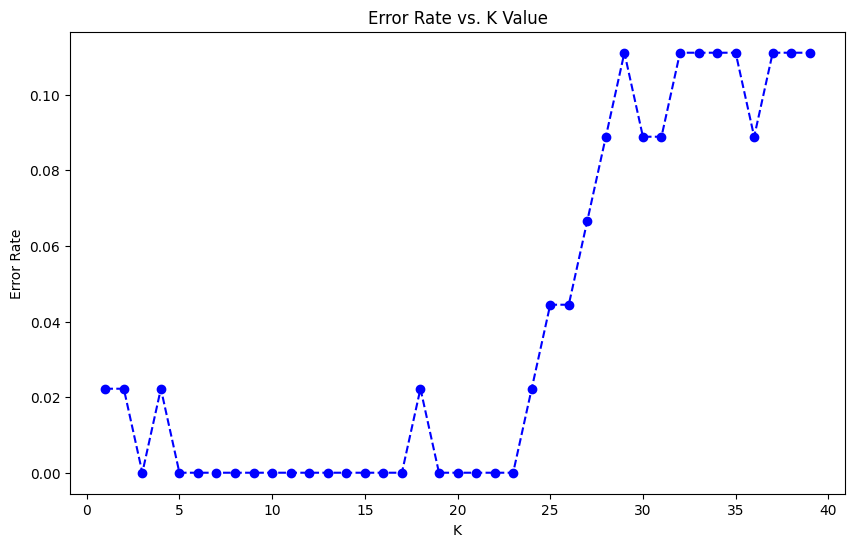

In [22]:
# Plotting the results
plt.figure(figsize=(10,6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

**The Geometry of KNN** The Euclidean distance between two points $P_1$ and $P_2$ in $n$-dimensional space is the length of the line segment connecting them. It is derived from the Pythagorean theorem.The formula for Euclidean distance $d$ is:$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
Where:$p, q$ = two points in $n$-dimensional space.$p_i, q_i$ = data elements (features) of those points.$n$ = the total number of features.

**Manual Implementation in Python** To understand how KNN "thinks," let’s calculate the distance between the first two rows of your scaled dataset without using a pre-built library.

Step 1: point1 - point2: Calculates the difference between the two flowers for each feature (Sepal Length, Sepal Width, etc.).

Step 2: np.square(...): Squares those differences. This ensures all values are positive (distance cannot be negative) and gives more weight to larger differences.

Step 3: np.sum(...): Adds all the squared differences together into a single number.

Step 4: np.sqrt(...): Takes the square root to return the value back to the original units (centimeters).

In [23]:
import numpy as np

In [24]:
# Select two sample points from our scaled features
point1 = X_test.iloc[0].values
point2 = X_test.iloc[1].values



In [25]:
# Manual Calculation:
# 1. Subtract the points
# 2. Square the differences
# 3. Sum them up
# 4. Take the square root
dist = np.sqrt(np.sum(np.square(point1 - point2)))

print(f"Euclidean distance between Point 1 and Point 2: {dist:.4f}")

Euclidean distance between Point 1 and Point 2: 3.1377


**Verification with Scipy**
In production, you would use optimized functions for these calculations. You can verify your manual math using the spatial module.

scipy: This is a powerful library built on top of NumPy, used for optimization, integration, and statistics.

spatial: This specific module contains functions for distance calculations, point-set transformations, and spatial data structures (like KD-trees, which KNN uses internally to speed up searches).

In [26]:
from scipy.spatial import distance

sci_dist = distance.euclidean(point1, point2)
print(f"Scipy verified distance: {sci_dist:.4f}")

Scipy verified distance: 3.1377


The Theory of $K$ Selection

$1$-NN (K=1): The model is highly flexible. It perfectly classifies every training point (zero error on training data) but is extremely sensitive to noise and outliers. This often leads to Overfitting.

Large K: As $K$ increases, the decision boundary becomes smoother. While this reduces the impact of noise, a $K$ that is too large will ignore local patterns. This leads to Underfitting.

**Multi-Model Comparison Script** We will iterate through different $K$ values and store their accuracy scores to see how the model stabilizes.

In [27]:
from sklearn.metrics import accuracy_score

These values are likely chosen to represent different "regimes" of the KNN algorithm:

$K=1$ (The Extreme): The most complex model. It is highly sensitive to noise and outliers (High Variance).

$K=2, 3$ (Low $K$): Still complex, but slightly more stable than $K=1$.

$K=10$ (Medium $K$): Often a "sweet spot" for small datasets like Iris, balancing local detail with general patterns.

$K=25$ (High $K$): A very "blunt" model. It looks at a huge portion of the dataset (nearly 25% of the training set) to make a decision, which can wash out subtle differences between species (High Bias).

In [ ]:
# Define the K values we want to compare
k_values = [1, 2, 3, 10, 25]
results = {}

In each iteration, the code:

Re-initializes the model with the new $K$ value.

Re-fits it to the training data. (Note: Since KNN is a "lazy learner," this is just the model reorganizing its memory of the 105 training flowers).

Tests the model's logic on the 45 flowers in the test set.

accuracy_score: Calculates the simple ratio of correct predictions to total predictions.

results[k]: By storing these in a dictionary, you can easily access them later for plotting or reporting.

In [ ]:
for k in k_values:
    # Initialize and train
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Store Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[k] = acc
    print(f"Accuracy for {k}-NN: {acc:.4f}")

Accuracy for 1-NN: 0.9778
Accuracy for 2-NN: 0.9778
Accuracy for 3-NN: 1.0000
Accuracy for 10-NN: 1.0000
Accuracy for 25-NN: 0.9556


**Visualizing the Decision Boundary** To truly see the difference between $1$-NN and $K$-NN, we can visualize how the model "cuts" the feature space. (Note: For visualization, we typically only use the first two features of the dataset).

visualize the "mental map" of your KNN model. By reducing the Iris dataset to just two features, it creates a 2D surface where you can see exactly where the model decides one species ends and another begins. This is a powerful way to visualize Overfitting vs. Underfitting.

By taking only the first two features (usually Sepal Length and Sepal Width), the code creates a standard X and Y axis for a 2D plot.

Trade-off: The accuracy might be lower than your 4-feature model, but the goal here is geometric understanding, not maximum performance.

In [ ]:
def plot_knn_boundary(k, X, y):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X.iloc[:, :2], y) # Using first two features only

    # Create a mesh grid
    h = .02
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict across the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors='k', s=20)
    plt.title(f"Decision Boundary for K={k}")
    plt.show()



To color the background, the code creates a grid of tiny points (spaced by h=0.02).

np.c_: This flattens the grid into a list of coordinates so the KNN can process them.

Result: Z becomes a color map. Areas where the model predicts Setosa get one color, Versicolor another, and Virginica a third.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


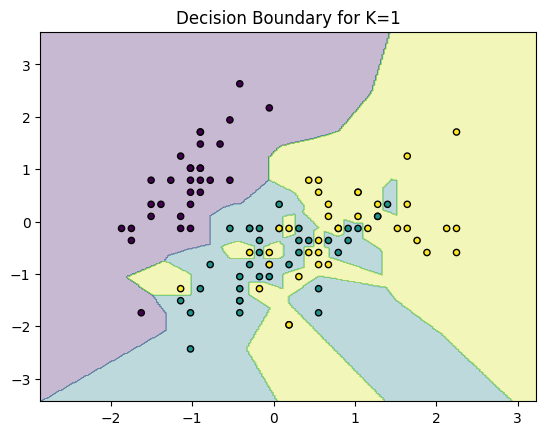

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


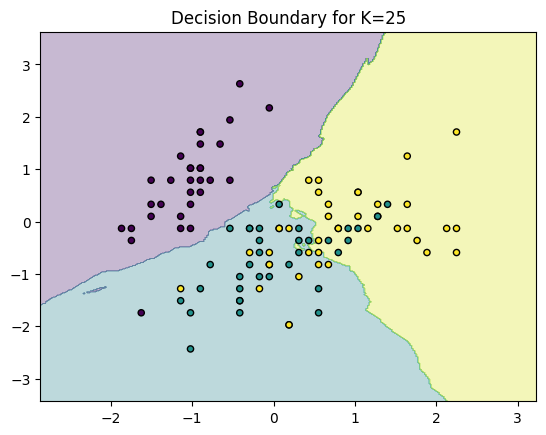

In [ ]:
# Compare 1-NN and 25-NN
plot_knn_boundary(1, X_train, y_train)
plot_knn_boundary(25, X_train, y_train)